<h2>**Name: Taha Ahmad**</h2>

<h1>**Importing Excel File for Dataset and Printing the first 5 colums**</h1>

In [4]:
import pandas as pd
import numpy as np
from scipy.stats import zscore
from sklearn.preprocessing import MinMaxScaler, StandardScaler, KBinsDiscretizer
import matplotlib.pyplot as plt
import plotly.express as px
data=pd.read_excel(r"C:\Users\LENOVO\Downloads\HR_comma_sep.xlsx") #Importing the excel file
data.head() #Checking the first five rows

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


<h1>**Dropping the unnecessary Columns**</h1>

In [5]:
cols = ['last_evaluation','left','Department']
data_cleaned = data.drop(columns =cols)
print(data_cleaned) #Cleaned the data

       satisfaction_level  number_project  average_montly_hours  \
0                    0.38               2                   157   
1                    0.80               5                   262   
2                    0.11               7                   272   
3                    0.72               5                   223   
4                    0.37               2                   159   
...                   ...             ...                   ...   
14994                0.40               2                   151   
14995                0.37               2                   160   
14996                0.37               2                   143   
14997                0.11               6                   280   
14998                0.37               2                   158   

       time_spend_company  Work_accident  promotion_last_5years  salary  
0                       3              0                      0     low  
1                       6              0       

<h1>**Checking the number of NaN/Missing Values**</h1>h1>

In [6]:
data.isnull().sum() #Checking the number of Nan values

satisfaction_level       0
last_evaluation          0
number_project           0
average_montly_hours     0
time_spend_company       0
Work_accident            0
left                     0
promotion_last_5years    0
Department               0
salary                   0
dtype: int64

<h1>**Detecting Outlier in Time Spent Company**</h1>

In [7]:
Q1=data['time_spend_company'].quantile(0.25)
Q3=data['time_spend_company'].quantile(0.75)
IQR=Q3 - Q1
lower_bound= Q1 - 1.5*IQR
upper_bound= Q3 + 1.5*IQR
outliers=[x for x in data['time_spend_company'] if x < lower_bound or x> upper_bound]
print(f'outliers in time_spend_company are {outliers}') #Detecting outliers in time spent company
data['time_spend_company']

outliers in time_spend_company are [6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6

0        3
1        6
2        4
3        5
4        3
        ..
14994    3
14995    3
14996    3
14997    4
14998    3
Name: time_spend_company, Length: 14999, dtype: int64

<h1>**Mapping the Salary with Particular Values Assumed and Printing the Cleaned Dataset**</h1>

In [8]:
salary_map = {"low": 25000, "medium": 40000, "high": 80000,
}
data_cleaned["salary_assumed"] = data_cleaned["salary"].map(salary_map) #Mapping the salary with particular values assumed
print(data_cleaned) #Printing the data cleaned 

       satisfaction_level  number_project  average_montly_hours  \
0                    0.38               2                   157   
1                    0.80               5                   262   
2                    0.11               7                   272   
3                    0.72               5                   223   
4                    0.37               2                   159   
...                   ...             ...                   ...   
14994                0.40               2                   151   
14995                0.37               2                   160   
14996                0.37               2                   143   
14997                0.11               6                   280   
14998                0.37               2                   158   

       time_spend_company  Work_accident  promotion_last_5years  salary  \
0                       3              0                      0     low   
1                       6              0     

<h1>**Discretizing Salary Ranges**</h1>

In [9]:
bins = [0,25000,40000,80000]
labels = ["low","medium","high"]
data_cleaned["Salary_Range"] = pd.cut(data_cleaned["salary_assumed"], bins = bins, labels=labels)
print(data_cleaned) #Discretizing Salary  ranges

       satisfaction_level  number_project  average_montly_hours  \
0                    0.38               2                   157   
1                    0.80               5                   262   
2                    0.11               7                   272   
3                    0.72               5                   223   
4                    0.37               2                   159   
...                   ...             ...                   ...   
14994                0.40               2                   151   
14995                0.37               2                   160   
14996                0.37               2                   143   
14997                0.11               6                   280   
14998                0.37               2                   158   

       time_spend_company  Work_accident  promotion_last_5years  salary  \
0                       3              0                      0     low   
1                       6              0     

<h1>**Calculating the Average Satisfaction Level and Plotting it against the Salary Types**</h1>

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_2608\3220981141.py:2: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



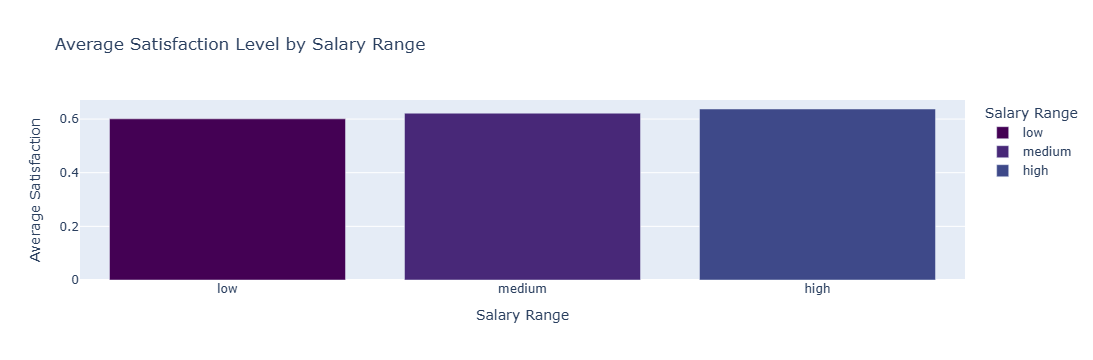

In [10]:

import plotly.express as px
avg_satisfaction = data_cleaned.groupby('Salary_Range')['satisfaction_level'].mean().reset_index() #Finding average satisfaction level
fig = px.bar(
    avg_satisfaction,
    x='Salary_Range',
    y='satisfaction_level',
    title='Average Satisfaction Level by Salary Range',
    labels={'Salary_Range': 'Salary Range', 'satisfaction_level': 'Average Satisfaction'},
    color='Salary_Range',  
    color_discrete_sequence=px.colors.sequential.Viridis  
)
fig.show() #Plotting Average satisfaction level against different salary types to see whether it is a factor affecting salary or not

<h1>**Calculating the Average Time Spent in the Company and Plotting it against the Salary Types**</h1>

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_2608\2091399361.py:1: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



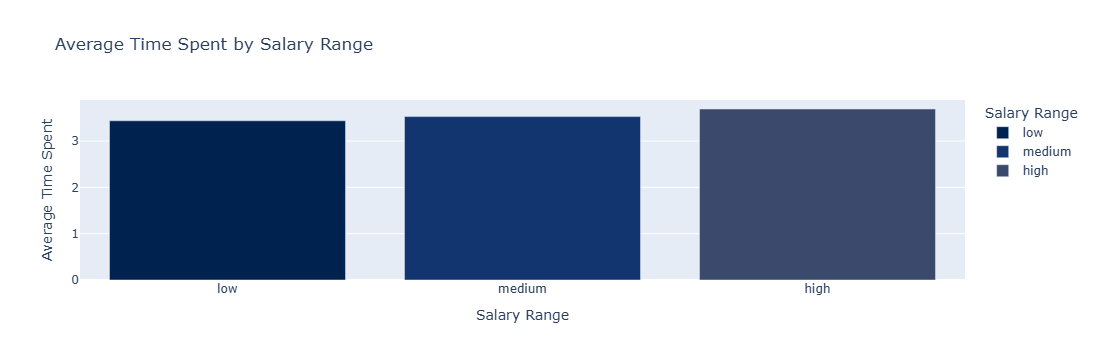

In [11]:
avg_time_spent = data_cleaned.groupby('Salary_Range')['time_spend_company'].mean().reset_index() #Finding average time spent in company
fig = px.bar(
    avg_time_spent,
    x='Salary_Range',
    y='time_spend_company',
    title='Average Time Spent by Salary Range',
    labels={'Salary_Range': 'Salary Range', 'time_spend_company': 'Average Time Spent'},
    color='Salary_Range', 
    color_discrete_sequence=px.colors.sequential.Cividis  
)
fig.show() #Plotting Average time spent in company against different salary types to see whether it is a factor affecting salary or not

<h1>**Calculating the Average Number of Projects Done and Plotting it against the Salary Types**</h1>

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_2608\1498847095.py:1: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



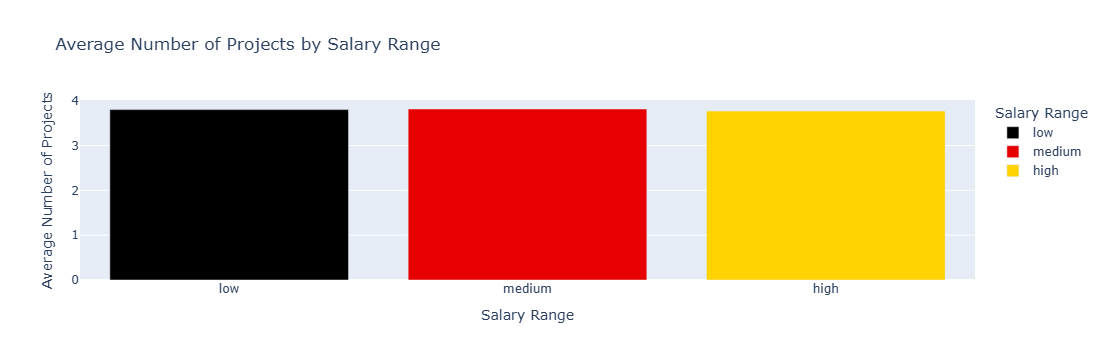

In [12]:
avg_no_of_projects = data_cleaned.groupby('Salary_Range')['number_project'].mean().reset_index() #Finding average number of projects
fig = px.bar(
    avg_no_of_projects,
    x='Salary_Range',
    y='number_project',
    title='Average Number of Projects by Salary Range',
    labels={'Salary_Range': 'Salary Range', 'number_project': 'Average Number of Projects'},
    color='Salary_Range', 
    color_discrete_sequence=px.colors.sequential.Hot  
)
fig.show() #Plotting Average number of projects against different salary types to see whether it is a factor affecting salary or not